In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
import astropy.units as u
from astropy.table import Table
from astropy.io import ascii
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord

from regions import Regions
from regions import PixCoord

from pyvo import registry

from astroquery.alma import Alma

basepath = '/home/j_poz/documents/milkywaylab/data'

In [2]:
tex_tbl = Table.read(f'{basepath}/tables/physical_properties_paper_tab_v3.tex', format='aastex')

props_tbl = Table.read(f'{basepath}/tables/HVCC_resampled_temp.ecsv')
tex_tbl.sort('ID Number')
props_tbl.sort('ID Number')

In [3]:
max_CS = fits.open(f'{basepath}/images/CS21_CubeMosaic_max.fits')
wcs = WCS(max_CS[0].header)

tbl = Table.read(f'{basepath}/tables/HVCC_resampled_again.ecsv')
regions = Regions.read(f'{basepath}/tables/HVCC_resampled_regions.reg', format='ds9')

oka_2012 = ascii.read(f'{basepath}/tables/oka_2012.ascii', format='tab', fast_reader=False)
oka_2022 = ascii.read(f'{basepath}/tables/oka_2022.ascii', format='tab', fast_reader=False)
oka_2022.remove_row(0)

whole_pv_CS = fits.open(f'{basepath}/images/CS21_CubeMosaic_PV_max.fits')

In [4]:
tex_tbl['Size'] = props_tbl['Size']
tex_tbl['Verticality'] = props_tbl['Verticality']
tex_tbl['deltaV'] = props_tbl['deltaV']
tex_tbl['Median Intensity'] = props_tbl['Median Intensity']
tex_tbl['V_LSR'] = props_tbl['V_LSR']

1998: 1998ApJS..118..455O - same as 1999\
1999: 1999ApJ...515..249O\
2001: 2001PASJ...53..787O - not in ACES area\
2012: 2012ApJS..201...14O\
2016: 2016ApJ...816L...7O - same as 2017\
2017: 2017NatAs...1..709O\
2022: 2022ApJS..261...13O download table 4 from paper 

takekawa 
2017: 2017ApJ...843L..11T - two objects found in paper\
2019: 2019PASJ...71S..21T\
2020: 2020ApJ...890..167T - also in takekawa 2017

kaneko 2023: 2023ApJ...942...46K - (0.09, -0.014)

if within spatial region and 30 kms of VLSR, then match

In [5]:
tbl.sort("ID Number")

evf_v_cent  = props_tbl['V_LSR']*u.km/u.s
evf_v_width = (props_tbl['max_v'] - props_tbl['min_v'])

reg_pix_list = [reg.to_pixel(WCS(max_CS[0].header)) for reg in regions]

In [6]:
oka_2012_coords = SkyCoord(oka_2012['l'], oka_2012['b'], frame='galactic', unit='deg')
oka_2012_pix = PixCoord.from_sky(oka_2012_coords, wcs)

matched_12 = []
matched_22 = []
no_vmatch_12 = []
no_vmatch_22 = []
match_imbh = []
no_vmatch_imbh = []
matched = []

for i in range(len(reg_pix_list)):
    if reg_pix_list[i].contains(oka_2012_pix).any() == True:
        CS_vlsr = evf_v_cent[i]
        CS_v_max, CS_v_min = tbl['max_v'][i], tbl['min_v'][i]
        oka_ind = np.where(reg_pix_list[i].contains(oka_2012_pix)==True)[0]
        if (np.abs(tbl['V_LSR'][i]-oka_2012['V_LSR'][oka_ind]) < 30).any():
            matched_12.append((i, 'a', oka_2012['Number'][oka_ind]))
        else:
            del_v = np.max(np.abs(tbl['V_LSR'][i]-oka_2012['V_LSR'][oka_ind]))
            no_vmatch_12.append((tbl['V_LSR'][i], tbl['min_v'][i], tbl['max_v'][i], oka_2012['V_LSR'][oka_ind[np.where(np.abs(tbl['V_LSR'][i]-oka_2012['V_LSR'][oka_ind])==del_v)]].value))

oka_2022_coords = SkyCoord(oka_2022['l'], oka_2022['b'], frame='galactic', unit='deg')
oka_2022_pix = PixCoord.from_sky(oka_2022_coords, wcs)
oka_2022['V _LSR'] = np.float64(oka_2022['V _LSR'])

for i in range(len(reg_pix_list)):
    if reg_pix_list[i].contains(oka_2022_pix).any() == True:
        CS_vlsr = evf_v_cent[i]
        CS_v_max, CS_v_min = tbl['max_v'][i], tbl['min_v'][i]
        oka_ind = np.where(reg_pix_list[i].contains(oka_2022_pix)==True)[0]
        #print(oka_ind)
        if (np.abs(tbl['V_LSR'][i]-oka_2022['V _LSR'][oka_ind]) < 30).any():
            matched_22.append((i, 'b', oka_2022['id'][oka_ind]))
        else:
            del_v = np.max(np.abs(tbl['V_LSR'][i]-oka_2022['V _LSR'][oka_ind]))
            no_vmatch_22.append((tbl['min_v'][i], tbl['max_v'][i], oka_2022['V _LSR'][oka_ind].value))

imbh_candidates = [['c', 0.02, -0.02, 100, 'CO 0.02-0.02'], ['', -0.4, -0.22, -55, ''], ['d', -0.009, -0.044, -50, 'HCN–0.009–0.044'], 
                ['d', -0.085, -0.094, -40, ''], ['', -0.31, 0.11, -165, ''], ['', -0.09, -0.14, -112, '']]

imbh_coords = SkyCoord([l[1] for l in imbh_candidates], [b[2] for b in imbh_candidates], frame='galactic', unit='deg')
imbh_pix = PixCoord.from_sky(imbh_coords, wcs)
imbh_vlsr = np.array([v[3] for v in imbh_candidates])

for i in range(len(reg_pix_list)):
    if reg_pix_list[i].contains(imbh_pix).any() == True:
        CS_vlsr = evf_v_cent[i]
        oka_ind = np.where(reg_pix_list[i].contains(imbh_pix)==True)[0]
        if (np.abs(tbl['V_LSR'][i]-(imbh_vlsr[oka_ind])) <= 30).any():
            match_imbh.append((i, imbh_candidates[oka_ind[0]][0], imbh_candidates[oka_ind[0]][4]))
        else:
            del_v = np.max(np.abs(tbl['V_LSR'][i]-imbh_vlsr[oka_ind]))
            no_vmatch_imbh.append((tbl['min_v'][i], tbl['max_v'][i], imbh_vlsr[oka_ind]))

/home/j_poz/anaconda3/lib/python3.13/site-packages/regions/shapes/rectangle.py:205: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Rectangle(xy=xy, width=width, height=height,


(0.0, 11000.0)

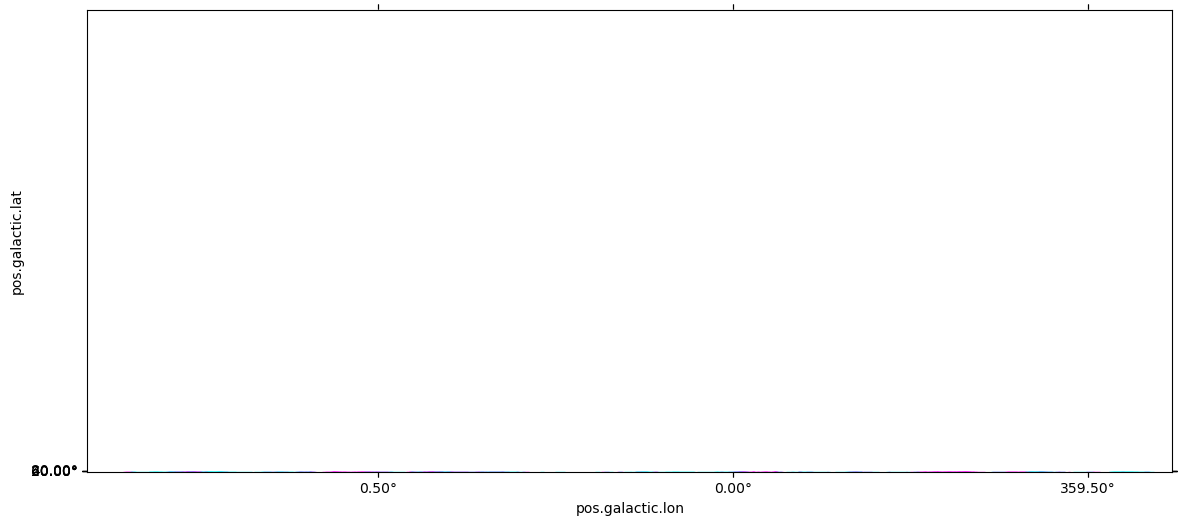

In [12]:
fig = plt.figure(figsize=(14,6))
ax = fig.add_subplot(projection=WCS(max_CS[0].header))

lon = ax.coords['glon']
lat = ax.coords['glat']
lon.set_major_formatter('d.dd')
lat.set_major_formatter('d.dd')

im = ax.imshow(max_CS[0].data, cmap='Greys', origin = 'lower', vmin = -0.1, vmax = 0.4, aspect='auto')

for i, reg in enumerate(list(reg_pix_list)):
    if i<=163:
        color='fuchsia'
    else:
        color='cyan'
    reg.plot(ax=ax, color=color, linewidth=1)
    
for evf in matched_22:
    ax.scatter(evf[2].l, evf[2].b, c='r', marker='*', s=20, transform=ax.get_transform('galactic'))

ax.set_xlim(0, 11000)


how many candidates are within the ACES field
percentage overlap with HVCC catalog
how many overlap but not velocity-wise

In [11]:
aces_mask = max_CS[0].data

In [12]:
aces_mask[np.where(~np.isnan(aces_mask))] = 1

In [7]:
o = 0
for i, coord in enumerate(list(oka_2012_pix)):
    try:
        if aces_mask[round(coord.y), round(coord.x)] == 1:
            o+=1
    except IndexError:
        continue

t = 0       
for i, coord in enumerate(list(oka_2022_pix)):
    try:
        if aces_mask[round(coord.y), round(coord.x)] == 1:
            t+=1
    except IndexError:
        continue

k=0
for i, coord in enumerate(list(imbh_pix)):
    try:
        if aces_mask[round(coord.y), round(coord.x)] == 1:
            k+=1
    except IndexError:
        continue

NameError: name 'aces_mask' is not defined

In [8]:
len(matched_12)

9

In [9]:
len(matched_22)

37

In [10]:
match_imbh

[(66, 'd', 'HCN–0.009–0.044'), (206, 'c', 'CO 0.02-0.02')]

In [32]:
previous_id=np.full(shape=len(tex_tbl), fill_value='--', dtype= '<U15')
ref = np.full(shape=len(tex_tbl), fill_value='--', dtype='<U15')

In [33]:
for match in matched_12:
    previous_id[match[0]] = match[2].data[0]
    ref[match[0]] = match[1]

for match in matched_22:
    if previous_id[match[0]] == '--':
        previous_id[match[0]] = match[2].data[0]
        ref[match[0]] = match[1]
    else:
        previous_id[match[0]] = previous_id[match[0]]+', '+str(match[2].data[0])
        ref[match[0]] = ref[match[0]] + ', '+match[1]

for match in match_imbh:
    if previous_id[match[0]] == '--':
        previous_id[match[0]] = match[2]
        ref[match[0]] = match[1]
    else:
        previous_id[match[0]] =previous_id[match[0]]+', '+match[2]
        ref[match[0]] = ref[match[0]]+', '+match[1]

In [34]:
if 'Previous Reference' in tex_tbl.colnames:
    tex_tbl.remove_columns(['Previous ID', 'Previous Reference'])
    
tex_tbl.add_columns([previous_id, ref], names=['Previous ID', 'Previous Reference'])

#tex_tbl.sort('l')

In [62]:
tex_tbl.write(f'{basepath}/tables/physical_properties_paper_tab_v3.tex', format='aastex', overwrite=True)

In [88]:
props_tbl.write(f'{basepath}/tables/full_table.ecsv', overwrite=True)

In [10]:
tbl

EVF Name,ID Number,l,b,deltal,deltab,V_LSR,deltaV,Verticality,Size,Median Intensity,Spectrum FWHM,min_v,max_v,Classification Comments,dendro_match
str16,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str55,float64
EVF-0.582_-0.062,18,-0.582,-0.062,0.007,0.009,-71.256,19.298,2956.818,1.454,0.166,nan,-78.678,-59.38,--,1899.0
EVF-0.561_-0.174,170,-0.561,-0.174,0.063,0.065,-59.38,105.399,1638.604,5.506,0.11,nan,-111.337,-5.938,nan,nan
EVF-0.558_-0.182,169,-0.558,-0.182,0.059,0.038,-59.38,90.554,1675.466,4.6,0.123,nan,-111.337,-20.783,nan,nan
EVF-0.551_-0.192,171,-0.551,-0.192,0.038,0.018,-23.752,62.349,3562.81,3.111,0.112,nan,-83.132,-20.783,nan,nan
EVF-0.549_-0.118,216,-0.549,-0.118,0.028,0.037,66.802,50.473,1653.248,3.304,0.109,nan,37.112,87.585,nan,nan
EVF-0.548_-0.112,12,-0.548,-0.112,0.004,0.009,-50.473,17.814,4138.046,1.772,0.165,nan,-65.318,-47.504,--,2812.0
EVF-0.507_-0.045,19,-0.507,-0.045,0.019,0.011,-62.349,16.329,839.907,1.999,0.137,nan,-72.74,-56.411,Dendrogram detection doesn't meet verticality threshold,nan
EVF-0.507_-0.212,6,-0.507,-0.212,0.001,0.001,-115.79,5.938,4275.886,1.568,0.181,nan,-118.759,-112.821,--,162.0
EVF-0.493_-0.222,164,-0.493,-0.222,0.028,0.017,-127.666,44.535,3086.38,2.121,0.112,nan,-146.965,-102.43,nan,nan


In [9]:
tbl[np.where(tbl['dendro_match']==np.nan)]

EVF Name,ID Number,l,b,deltal,deltab,V_LSR,deltaV,Verticality,Size,Median Intensity,Spectrum FWHM,min_v,max_v,Classification Comments,dendro_match
str16,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str55,float64


In [6]:
tex_tbl

HVCC Name,ID Number,l,b,V_LSR,deltaV,Verticality,Size,Median Intensity,Fitted FWHM,Peaks,PV Classification,Detection Method,Previous ID,Previous Reference
str15,int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,str5,str1,str15,str4
CS -0.282+0.055,0,-0.282,0.055,-44.535,38.597,1208.315,3.21,0.116,19.0,1,CU,e,--,--
CS -0.261+0.024,1,-0.261,0.024,-93.523,59.38,1566.137,3.672,0.059,13.9,4,CU,e,"55, 63","a, b"
CS -0.307+0.03,2,-0.307,0.03,-32.659,35.628,1215.812,3.043,0.071,24.8,2,S,e,60,b
CS -0.462-0.256,3,-0.462,-0.256,-96.492,31.174,1700.607,1.657,0.088,30.7,2,S,e,--,--
CS -0.382-0.253,4,-0.382,-0.253,20.783,34.143,979.493,3.299,0.136,5.5,2,S,n,--,--
CS -0.401-0.131,5,-0.401,-0.131,10.391,43.05,863.482,4.378,0.077,46.0,2,CU,e,52,b
CS -0.507-0.212,6,-0.507,-0.212,-117.275,23.752,1401.931,1.173,0.163,13.5,2,CL,e,--,--
CS -0.432-0.195,7,-0.432,-0.195,-26.721,23.752,2552.698,1.274,0.136,19.7,2,"CU, S",e,--,--
CS -0.473-0.137,8,-0.473,-0.137,-71.256,22.267,1471.043,0.82,0.129,20.6,1,S,e,--,--


In [61]:
props_tbl[19]

EVF Name,ID Number,l,b,deltal,deltab,V_LSR,deltaV,Verticality,Size,Median Intensity,Spectrum FWHM,min_v,max_v,Classification Comments,dendro_match,detection_method
str16,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str55,float64,str1
EVF-0.507_-0.045,19,-0.507,-0.045,0.029,0.021,-62.349,29.69,1027.858,1.403,0.084,nan,-80.163,-50.473,Dendrogram detection doesn't meet verticality threshold,nan,n


In [ ]:

good_data = QTable(names= (['Number','l (deg)', 'b (deg)','V_LSR (km s^-1)', 'Deltal (deg)', 'Deltab (deg)',
                          'DeltaV (km s^-1)', 'min_v', 'max_v']),
                units=['','deg', 'deg','km / s', 'deg', 'deg', 'km / s', 'km / s', 'km / s'] )

min_verticality=1000 * u.km/( u.s * u.deg)

for row in evf_table:
    verticality=(row['DeltaV'])/(row['Deltal'])
    
    if len(good_data)==0 and verticality>=min_verticality and row['Deltal']!=0:
        good_data.add_row(row)

    else:
        lb_sep=np.sqrt((row['l']-good_data['l'])**2+(row['b']-good_data['b'])**2)
        min_lb_idx=np.argmin(lb_sep)
        v_sep=row['V_LSR (km s^-1)']-good_data['V_LSR (km s^-1)']
        min_v_idx=np.argmin(v_sep)
        
        if np.min(lb_sep)<0.01*u.deg and min_lb_idx==min_v_idx and np.min(v_sep)<15*u.km/u.s:
            continue
        else verticality>=min_verticality:
            good_data.add_row(row)
